# How one initialization multiplier compounds through 30 ReLU layers

This notebook runs one controlled experiment from Lecture 6. We construct the
same untrained network three times and change only one number:

$$
W_\ell^{(\alpha)}=\alpha W_\ell^{(1)},
\qquad \alpha\in\{0.5,1,1.5\}.
$$

For each hidden layer, the $\alpha=1$ reference uses He/Kaiming-normal
initialization. The other two runs use exactly the same sampled weight
directions, made narrower or wider. $\alpha$ is an initialization multiplier;
it is **not** the learning rate. The output-layer convention is stated below.

The network and tensor shapes are

$$
X=H_0\;(900\!\times\!2)
\longrightarrow
[\,\alpha W_1\rightarrow\operatorname{ReLU}\,]
\longrightarrow H_1\;(900\!\times\!128)
\longrightarrow\cdots\longrightarrow
H_{30}\;(900\!\times\!128)
\longrightarrow
\alpha W_{31}\longrightarrow O\;(900\!\times\!3).
Here $O$ is the batch of logits; one example's logit vector is $\boldsymbol{o}$.
$$

`forward` returns all $H_\ell$ explicitly. No hooks are needed.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

torch.set_num_threads(min(4, torch.get_num_threads()))

INK = "#23373B"
BLUE = "#2B6CB0"
GREEN = "#14B03D"
RED = "#D64550"
MUTED = "#6E7F82"
COLORS = {0.5: BLUE, 1.0: GREEN, 1.5: RED}

plt.rcParams.update({
    "figure.figsize": (8.5, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "text.color": INK,
})

def rms(tensor):
    # Root mean square over every entry of a tensor.
    return tensor.detach().float().square().mean().sqrt().item()

print("PyTorch", torch.__version__)

PyTorch 2.13.0


## 1 · Fix everything except $\alpha$

The data are a fixed three-class spiral. Each hidden affine map has zero bias.
For a layer with `fan_in` inputs, the reference weights are sampled from
$\mathcal N(0,2/\text{fan\_in})$, then multiplied by $\alpha$.

We also scale the final $128\rightarrow3$ map. This is a deliberate convention
for this controlled experiment; no ReLU follows that map.

In [2]:
def make_spiral(n_per_class=300, classes=3, noise=0.2, seed=7):
    generator = torch.Generator().manual_seed(seed)
    points, labels = [], []
    for class_id in range(classes):
        radius = torch.linspace(0.05, 1.0, n_per_class)
        angle = (
            torch.linspace(class_id * 4.0, (class_id + 1) * 4.0, n_per_class)
            + noise * torch.randn(n_per_class, generator=generator)
        )
        points.append(torch.stack(
            (radius * torch.sin(angle), radius * torch.cos(angle)), dim=1
        ))
        labels.append(torch.full((n_per_class,), class_id, dtype=torch.long))
    X = torch.cat(points)
    y = torch.cat(labels)
    order = torch.randperm(len(X), generator=generator)
    return X[order], y[order]


def initialize_linear(layer, alpha):
    nn.init.normal_(layer.weight, mean=0.0, std=math.sqrt(2 / layer.in_features))
    nn.init.zeros_(layer.bias)
    with torch.no_grad():
        layer.weight.mul_(alpha)


class ThirtyLayerMLP(nn.Module):
    def __init__(self, alpha, depth=30, width=128, seed=11):
        super().__init__()
        torch.manual_seed(seed)  # reset: every alpha starts from the same samples
        self.hidden = nn.ModuleList()
        fan_in = 2
        for _ in range(depth):
            layer = nn.Linear(fan_in, width)
            initialize_linear(layer, alpha)
            self.hidden.append(layer)
            fan_in = width
        self.output = nn.Linear(width, 3)
        initialize_linear(self.output, alpha)

    def forward(self, x, retain_activation_grads=False):
        activations = []
        for layer in self.hidden:
            x = F.relu(layer(x))
            if retain_activation_grads:
                x.retain_grad()
            activations.append(x)
        return self.output(x), activations


X, y = make_spiral()
ALPHAS = (0.5, 1.0, 1.5)
models = {alpha: ThirtyLayerMLP(alpha) for alpha in ALPHAS}

# Check all 31 weight matrices, not only one illustrative layer.
reference_weights = [
    *(layer.weight.detach() for layer in models[1.0].hidden),
    models[1.0].output.weight.detach(),
]
for alpha in ALPHAS:
    candidate_weights = [
        *(layer.weight.detach() for layer in models[alpha].hidden),
        models[alpha].output.weight.detach(),
    ]
    assert len(candidate_weights) == 31
    assert all(
        torch.allclose(candidate, alpha * reference, rtol=1e-6, atol=1e-8)
        for candidate, reference in zip(candidate_weights, reference_weights)
    )
    assert all(torch.count_nonzero(layer.bias) == 0 for layer in models[alpha].hidden)
    assert torch.count_nonzero(models[alpha].output.bias) == 0

print("data:", tuple(X.shape), "labels:", tuple(y.shape))
print("verified: all 31 weight matrices use the same base directions")
print("changed across runs: alpha only")

data: (900, 2) labels: (900,)
verified: all 31 weight matrices use the same base directions
changed across runs: alpha only


## 2 · Predict before running the forward pass

For $\alpha>0$, ReLU preserves a positive scale:

$$\operatorname{ReLU}(\alpha u)=\alpha\operatorname{ReLU}(u).$$

Zero biases let the scale pass through the affine maps without an added term.
Work through the first two hidden layers:

$$
H_1^{(\alpha)}=\operatorname{ReLU}(\alpha XW_1^\top)
=\alpha H_1^{(1)},
$$

$$
H_2^{(\alpha)}
=\operatorname{ReLU}(\alpha H_1^{(\alpha)}W_2^\top)
=\alpha^2H_2^{(1)}.
$$

**Prediction:** hidden layer $\ell$ satisfies
$H_\ell^{(\alpha)}=\alpha^\ell H_\ell^{(1)}$. Therefore its RMS should also
gain one factor of $\alpha$ per layer. At layer 30, the relative factors are
$0.5^{30}\approx9.31\times10^{-10}$ and
$1.5^{30}\approx1.92\times10^5$.

In [3]:
with torch.no_grad():
    forward_results = {alpha: models[alpha](X) for alpha in ALPHAS}

reference_activations = forward_results[1.0][1]
relative_errors = {}

print(f"{'alpha':>5} {'layer':>6} {'predicted RMS':>15} {'measured RMS':>15} {'relative error':>16}")
for alpha in (0.5, 1.5):
    layer_errors = []
    for layer_number, (actual, reference) in enumerate(
        zip(forward_results[alpha][1], reference_activations), start=1
    ):
        predicted = (alpha ** layer_number) * reference
        relative_error = rms(actual - predicted) / max(rms(predicted), 1e-30)
        layer_errors.append(relative_error)

        # Positive scaling should preserve every ReLU gate as well.
        assert torch.equal(actual > 0, reference > 0)

        if layer_number in (1, 10, 20, 30):
            print(
                f"{alpha:5.1f} {layer_number:6d} {rms(predicted):15.6e} "
                f"{rms(actual):15.6e} {relative_error:16.3e}"
            )
    relative_errors[alpha] = layer_errors

# Float32 matrix multiplication introduces tiny rounding differences for 1.5.
assert max(relative_errors[0.5]) < 1e-12
assert max(relative_errors[1.5]) < 2e-6
print("maximum tensor-level relative RMS error:", {
    alpha: f"{max(errors):.2e}" for alpha, errors in relative_errors.items()
})
print("layer-30 reference RMS:", f"{rms(reference_activations[-1]):.6f}")

alpha  layer   predicted RMS    measured RMS   relative error
  0.5      1    1.950753e-01    1.950753e-01        0.000e+00
  0.5     10    4.125119e-04    4.125119e-04        0.000e+00
  0.5     20    5.574394e-07    5.574394e-07        0.000e+00
  0.5     30    1.021539e-09    1.021539e-09        0.000e+00
  1.5      1    5.852258e-01    5.852258e-01        5.932e-08
  1.5     10    2.435842e+01    2.435842e+01        4.872e-07
  1.5     20    1.943671e+03    1.943671e+03        6.582e-07
  1.5     30    2.103259e+05    2.103258e+05        6.738e-07
maximum tensor-level relative RMS error: {0.5: '0.00e+00', 1.5: '7.50e-07'}
layer-30 reference RMS: 1.096869


The equality is checked on the complete $900\times128$ tensor at every hidden
layer. It is not a fit to the plotted RMS values. The small nonzero discrepancy
for $\alpha=1.5$ is ordinary float32 rounding.

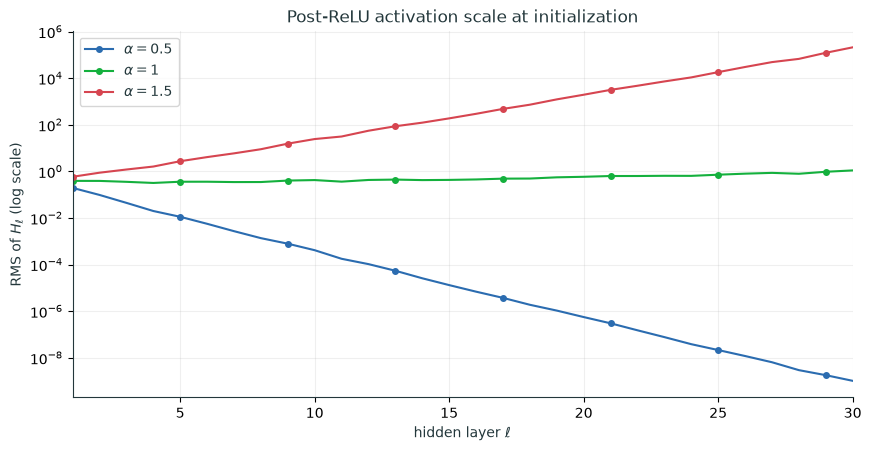

alpha=0.5: layer 1 RMS=1.950753e-01; layer 30 RMS=1.021539e-09
alpha=1.0: layer 1 RMS=3.901506e-01; layer 30 RMS=1.096869e+00
alpha=1.5: layer 1 RMS=5.852258e-01; layer 30 RMS=2.103258e+05


In [4]:
layers = np.arange(1, 31)
fig, ax = plt.subplots(figsize=(8.6, 4.4), constrained_layout=True)
for alpha in ALPHAS:
    activation_rms = [rms(h) for h in forward_results[alpha][1]]
    ax.plot(layers, activation_rms, color=COLORS[alpha], marker="o",
            markevery=(0, 4), markersize=4, label=fr"$\alpha={alpha:g}$")

ax.set_yscale("log")
ax.set_xlim(1, 30)
ax.set_xlabel(r"hidden layer $\ell$")
ax.set_ylabel(r"RMS of $H_\ell$ (log scale)")
ax.set_title("Post-ReLU activation scale at initialization")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

for alpha in ALPHAS:
    first = rms(forward_results[alpha][1][0])
    last = rms(forward_results[alpha][1][-1])
    print(f"alpha={alpha:3.1f}: layer 1 RMS={first:.6e}; layer 30 RMS={last:.6e}")

## 3 · What changes before the first optimizer step?

The output map supplies one additional factor of $\alpha$, so
$O^{(\alpha)}\approx\alpha^{31}O^{(1)}$. Multiplying all logits by a positive
number leaves `argmax` unchanged, but softmax probabilities do change.

Before running the next cell, predict:

1. Which run will produce probabilities close to $(1/3,1/3,1/3)$?
2. Which run will produce almost one-hot probabilities?
3. If two thirds of the unchanged predictions are wrong, what happens to
   cross-entropy when those wrong predictions become extremely confident?

In [5]:
forward_metrics = {}
reference_prediction = forward_results[1.0][0].argmax(dim=1)

print(
    f"{'alpha':>5} {'logit RMS':>13} {'mean max p':>12} "
    f"{'mean entropy':>14} {'CE loss':>13} {'accuracy':>10}"
)
for alpha in ALPHAS:
    logits = forward_results[alpha][0]
    probabilities = logits.softmax(dim=1)
    entropy = -(
        probabilities
        * probabilities.clamp_min(torch.finfo(probabilities.dtype).tiny).log()
    ).sum(dim=1).mean()
    loss = F.cross_entropy(logits, y)
    prediction = logits.argmax(dim=1)
    accuracy = (prediction == y).float().mean()

    assert torch.equal(prediction, reference_prediction)
    assert torch.isfinite(logits).all()
    forward_metrics[alpha] = {
        "logit_rms": rms(logits),
        "max_probability": probabilities.max(dim=1).values.mean().item(),
        "entropy": max(entropy.item(), 0.0),
        "loss": loss.item(),
        "accuracy": accuracy.item(),
    }
    values = forward_metrics[alpha]
    print(
        f"{alpha:5.1f} {values['logit_rms']:13.6e} "
        f"{values['max_probability']:12.6f} {values['entropy']:14.6e} "
        f"{values['loss']:13.6e} {values['accuracy']:10.3f}"
    )

assert abs(forward_metrics[0.5]["loss"] - math.log(3)) < 1e-5
assert abs(forward_metrics[0.5]["max_probability"] - 1 / 3) < 1e-6
assert forward_metrics[1.5]["max_probability"] > 0.999
assert forward_metrics[1.5]["loss"] > 1e5
print("verified: the predicted class is identical for every example and every alpha")

alpha     logit RMS   mean max p   mean entropy       CE loss   accuracy
  0.5  4.916047e-10     0.333333   1.098612e+00  1.098612e+00      0.333
  1.0  1.055713e+00     0.584473   9.223707e-01  1.224224e+00      0.333
  1.5  3.036511e+05     1.000000  -0.000000e+00  1.893593e+05      0.333
verified: the predicted class is identical for every example and every alpha


The three models have the same untrained decision boundary and the same
one-third accuracy. Their numerical behavior is nevertheless very different:

- $\alpha=0.5$: the logits are effectively zero, so softmax is uniform and the
  loss is $\log 3$. The network cannot express preference between classes.
- $\alpha=1$: logits and probabilities remain at an order-one scale.
- $\alpha=1.5$: the same mostly wrong predictions become almost perfectly
  confident. Cross-entropy assigns a very large penalty to confident mistakes.

Large activations here are finite. This cell diagnoses an extreme starting
scale; it does not by itself prove that training will diverge.

## 4 · The backward pass sees the compounded scale too

We now backpropagate the same mean cross-entropy once. `X` is made a leaf tensor
so that `X.grad` stores $\partial L/\partial X$. The hidden activations call
`retain_grad()` only because we also want the full gradient trace.

The horizontal axis below is tensor location in the **forward** network.
Backpropagation travels from $H_{30}$ on the right toward $X$ on the left.

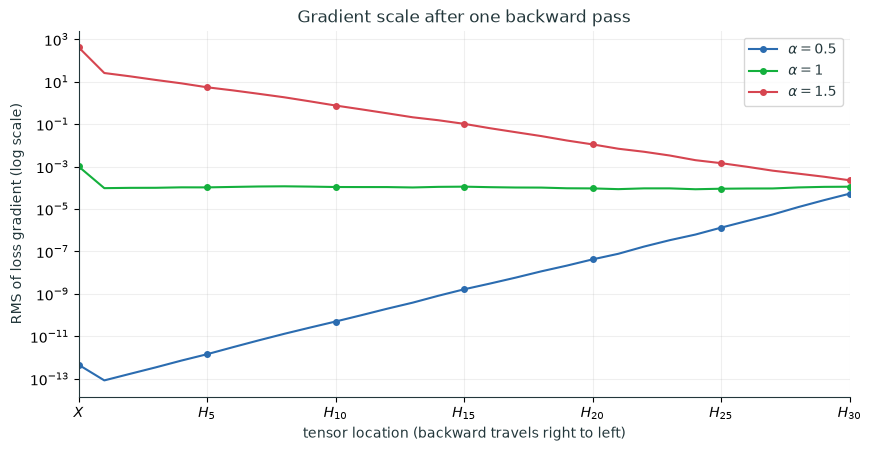

alpha      RMS(dL/dX)      RMS(dL/dH30)          loss
  0.5    4.569547e-13      5.276337e-05  1.098612e+00
  1.0    1.008809e-03      1.122285e-04  1.224224e+00
  1.5    4.153596e+02      2.252174e-04  1.893593e+05
all notebook assertions passed


In [6]:
gradient_rms = {}
losses = {}

for alpha in ALPHAS:
    models[alpha].zero_grad(set_to_none=True)
    X_leaf = X.detach().clone().requires_grad_(True)
    logits, activations = models[alpha](X_leaf, retain_activation_grads=True)
    loss = F.cross_entropy(logits, y)
    loss.backward()

    gradient_rms[alpha] = [rms(X_leaf.grad), *[rms(h.grad) for h in activations]]
    losses[alpha] = loss.item()
    assert all(math.isfinite(value) for value in gradient_rms[alpha])

fig, ax = plt.subplots(figsize=(8.6, 4.4), constrained_layout=True)
locations = np.arange(0, 31)
for alpha in ALPHAS:
    ax.plot(locations, gradient_rms[alpha], color=COLORS[alpha], marker="o",
            markevery=(0, 5), markersize=4, label=fr"$\alpha={alpha:g}$")
ax.set_yscale("log")
ax.set_xlim(0, 30)
ax.set_xticks([0, 5, 10, 15, 20, 25, 30],
              ["$X$", "$H_5$", "$H_{10}$", "$H_{15}$", "$H_{20}$", "$H_{25}$", "$H_{30}$"])
ax.set_xlabel("tensor location (backward travels right to left)")
ax.set_ylabel("RMS of loss gradient (log scale)")
ax.set_title("Gradient scale after one backward pass")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

print(f"{'alpha':>5} {'RMS(dL/dX)':>15} {'RMS(dL/dH30)':>17} {'loss':>13}")
for alpha in ALPHAS:
    print(
        f"{alpha:5.1f} {gradient_rms[alpha][0]:15.6e} "
        f"{gradient_rms[alpha][-1]:17.6e} {losses[alpha]:13.6e}"
    )

assert gradient_rms[0.5][0] < 1e-12
assert 1e-4 < gradient_rms[1.0][0] < 1e-2
assert gradient_rms[1.5][0] > 1e2
print("all notebook assertions passed")

## Interpretation

At $H_{30}$, the loss gradients are still numerically modest. Repeated
multiplication by 30 hidden weight matrices determines what reaches the input:

- with $\alpha=0.5$, the input-gradient RMS is about $4.6\times10^{-13}$;
- with $\alpha=1$, it is about $1.0\times10^{-3}$;
- with $\alpha=1.5$, it is about $4.2\times10^2$.

The cross-entropy derivative also depends on softmax confidence, so these three
gradient traces are measured consequences, not a claim that every gradient is
exactly $\alpha^{30}$ times the reference.

### What this experiment establishes

1. A per-layer initialization multiplier compounds through depth.
2. Post-ReLU activation RMS makes that scale visible.
3. Unchanged class predictions can hide uniform or saturated probabilities.
4. The same initialization choice changes the scale of the signal that reaches
   early layers during backpropagation.

No optimizer step was taken. Training behavior is the next experiment, not a
conclusion smuggled into this one.